In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

plt.style.use("ggplot")

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


In [2]:
import pandas as pd

fund_master = pd.read_csv("data/raw/Bluestock_MF_Datasets/01_fund_master.csv")
nav = pd.read_csv("data/processed/clean_nav_history.csv")
aum = pd.read_csv("data/raw/Bluestock_MF_Datasets/03_aum_by_fund_house.csv")
sip = pd.read_csv("data/raw/Bluestock_MF_Datasets/04_monthly_sip_inflows.csv")
category = pd.read_csv("data/raw/Bluestock_MF_Datasets/05_category_inflows.csv")
folio = pd.read_csv("data/raw/Bluestock_MF_Datasets/06_industry_folio_count.csv")
performance = pd.read_csv("data/processed/clean_scheme_performance.csv")
transactions = pd.read_csv("data/processed/clean_investor_transactions.csv")
holdings = pd.read_csv("data/raw/Bluestock_MF_Datasets/09_portfolio_holdings.csv")
benchmark = pd.read_csv("data/raw/Bluestock_MF_Datasets/10_benchmark_indices.csv")

print("All datasets loaded successfully!")

All datasets loaded successfully!


In [3]:
import os
print(os.getcwd())

C:\Users\harsh\OneDrive\Desktop\MutualFundAnalytics


In [4]:
datasets = {
    "Fund Master": fund_master,
    "NAV": nav,
    "AUM": aum,
    "SIP": sip,
    "Category": category,
    "Folio": folio,
    "Performance": performance,
    "Transactions": transactions,
    "Holdings": holdings,
    "Benchmark": benchmark,
}

for name, df in datasets.items():
    print(f"{name}: {df.shape}")

Fund Master: (40, 15)
NAV: (46000, 3)
AUM: (90, 5)
SIP: (48, 6)
Category: (144, 3)
Folio: (21, 6)
Performance: (40, 19)
Transactions: (32778, 13)
Holdings: (322, 8)
Benchmark: (8050, 3)


In [5]:
# Convert date column to datetime
nav["date"] = pd.to_datetime(nav["date"])

print(nav.head())

   amfi_code       date       nav
0     100016 2022-01-03  520.4608
1     100016 2022-01-04  515.0971
2     100016 2022-01-05  521.7239
3     100016 2022-01-06  515.7880
4     100016 2022-01-07  515.1639


In [6]:
print(nav.head(10))

   amfi_code       date       nav
0     100016 2022-01-03  520.4608
1     100016 2022-01-04  515.0971
2     100016 2022-01-05  521.7239
3     100016 2022-01-06  515.7880
4     100016 2022-01-07  515.1639
5     100016 2022-01-10  510.7136
6     100016 2022-01-11  513.5542
7     100016 2022-01-12  512.3195
8     100016 2022-01-13  510.2445
9     100016 2022-01-14  514.3636


In [7]:
print(nav.columns)

Index(['amfi_code', 'date', 'nav'], dtype='str')


In [8]:
print(nav["date"].head(20).tolist())

[Timestamp('2022-01-03 00:00:00'), Timestamp('2022-01-04 00:00:00'), Timestamp('2022-01-05 00:00:00'), Timestamp('2022-01-06 00:00:00'), Timestamp('2022-01-07 00:00:00'), Timestamp('2022-01-10 00:00:00'), Timestamp('2022-01-11 00:00:00'), Timestamp('2022-01-12 00:00:00'), Timestamp('2022-01-13 00:00:00'), Timestamp('2022-01-14 00:00:00'), Timestamp('2022-01-17 00:00:00'), Timestamp('2022-01-18 00:00:00'), Timestamp('2022-01-19 00:00:00'), Timestamp('2022-01-20 00:00:00'), Timestamp('2022-01-21 00:00:00'), Timestamp('2022-01-24 00:00:00'), Timestamp('2022-01-25 00:00:00'), Timestamp('2022-01-26 00:00:00'), Timestamp('2022-01-27 00:00:00'), Timestamp('2022-01-28 00:00:00')]


In [9]:
print(nav.dtypes)
print(nav["date"].isna().sum())

amfi_code             int64
date         datetime64[us]
nav                 float64
dtype: object
0


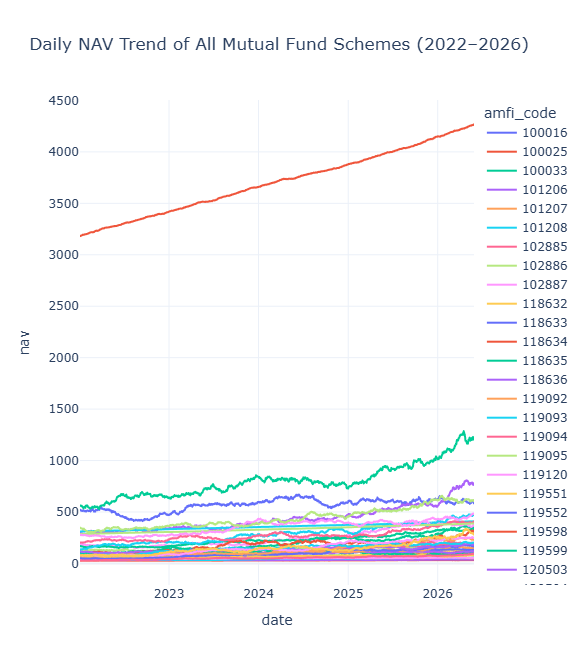

In [10]:
import plotly.express as px

fig = px.line(
    nav,
    x="date",
    y="nav",
    color="amfi_code",
    title="Daily NAV Trend of All Mutual Fund Schemes (2022–2026)"
)

fig.update_layout(
    template="plotly_white",
    width=1200,
    height=650
)

fig.show()

In [11]:
print(nav["date"].sample(20).tolist())

[Timestamp('2024-01-17 00:00:00'), Timestamp('2023-11-03 00:00:00'), Timestamp('2026-01-02 00:00:00'), Timestamp('2025-08-06 00:00:00'), Timestamp('2023-03-15 00:00:00'), Timestamp('2023-12-25 00:00:00'), Timestamp('2023-05-15 00:00:00'), Timestamp('2024-05-13 00:00:00'), Timestamp('2024-07-01 00:00:00'), Timestamp('2022-01-04 00:00:00'), Timestamp('2022-02-23 00:00:00'), Timestamp('2023-11-08 00:00:00'), Timestamp('2022-10-26 00:00:00'), Timestamp('2023-05-10 00:00:00'), Timestamp('2026-04-09 00:00:00'), Timestamp('2022-07-28 00:00:00'), Timestamp('2023-10-12 00:00:00'), Timestamp('2025-12-10 00:00:00'), Timestamp('2022-10-05 00:00:00'), Timestamp('2024-02-06 00:00:00')]


In [12]:
print(nav.columns.tolist())

['amfi_code', 'date', 'nav']


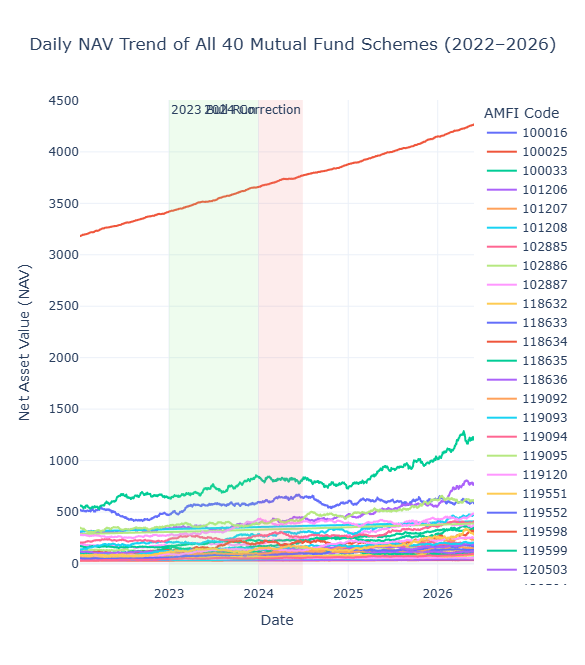

In [13]:
import plotly.express as px

fig = px.line(
    nav,
    x="date",
    y="nav",
    color="amfi_code",
    title="Daily NAV Trend of All 40 Mutual Fund Schemes (2022–2026)",
    labels={
        "date": "Date",
        "nav": "Net Asset Value (NAV)",
        "amfi_code": "AMFI Code"
    }
)

# Highlight 2023 Bull Run
fig.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    fillcolor="lightgreen",
    opacity=0.15,
    line_width=0,
    annotation_text="2023 Bull Run",
    annotation_position="top left"
)

# Highlight 2024 Market Correction
fig.add_vrect(
    x0="2024-01-01",
    x1="2024-06-30",
    fillcolor="lightcoral",
    opacity=0.15,
    line_width=0,
    annotation_text="2024 Correction",
    annotation_position="top right"
)

fig.update_layout(
    template="plotly_white",
    width=1300,
    height=650
)

fig.show()

In [14]:
fig.write_image("charts/nav_trend_all_schemes.png")

FileNotFoundError: [Errno 2] No such file or directory: 'charts\\nav_trend_all_schemes.png'

In [15]:
fig.write_image("charts/nav_trend_all_schemes.png")


FileNotFoundError: [Errno 2] No such file or directory: 'charts\\nav_trend_all_schemes.png'

In [16]:
import sys
print(sys.executable)

C:\Users\harsh\OneDrive\Desktop\MutualFundAnalytics\venv\Scripts\python.exe


In [17]:
import plotly
print(plotly.__version__)

6.8.0


In [18]:
import kaleido
print("Kaleido imported successfully")

Kaleido imported successfully


In [19]:
fig.write_image("charts/nav_trend_all_schemes.png", engine="kaleido")

C:\Users\harsh\AppData\Local\Temp\ipykernel_19976\3462352394.py:1: DeprecationWarning: 
Support for the 'engine' argument is deprecated and will be removed after September 2025.
Kaleido will be the only supported engine at that time.

  fig.write_image("charts/nav_trend_all_schemes.png", engine="kaleido")


FileNotFoundError: [Errno 2] No such file or directory: 'charts\\nav_trend_all_schemes.png'

In [20]:
import plotly.io as pio
print(pio.kaleido.scope)

In [21]:
import plotly.io as pio
print(pio.renderers.default)

plotly_mimetype


In [22]:
print(aum.head())

         date           fund_house  aum_lakh_crore  aum_crore  num_schemes
0  2022-03-31      SBI Mutual Fund            6.05     605000          186
1  2022-03-31  ICICI Prudential MF            4.65     465000          216
2  2022-03-31     HDFC Mutual Fund            4.35     435000          195
3  2022-03-31      Nippon India MF            2.70     270000          177
4  2022-03-31    Kotak Mahindra MF            2.70     270000          168


In [23]:
print(aum.columns.tolist())

['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes']


In [24]:
# Convert date column
aum["date"] = pd.to_datetime(aum["date"])

# Extract year
aum["year"] = aum["date"].dt.year

aum.head()

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes,year
0,2022-03-31,SBI Mutual Fund,6.05,605000,186,2022
1,2022-03-31,ICICI Prudential MF,4.65,465000,216,2022
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195,2022
3,2022-03-31,Nippon India MF,2.70,270000,177,2022
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168,2022


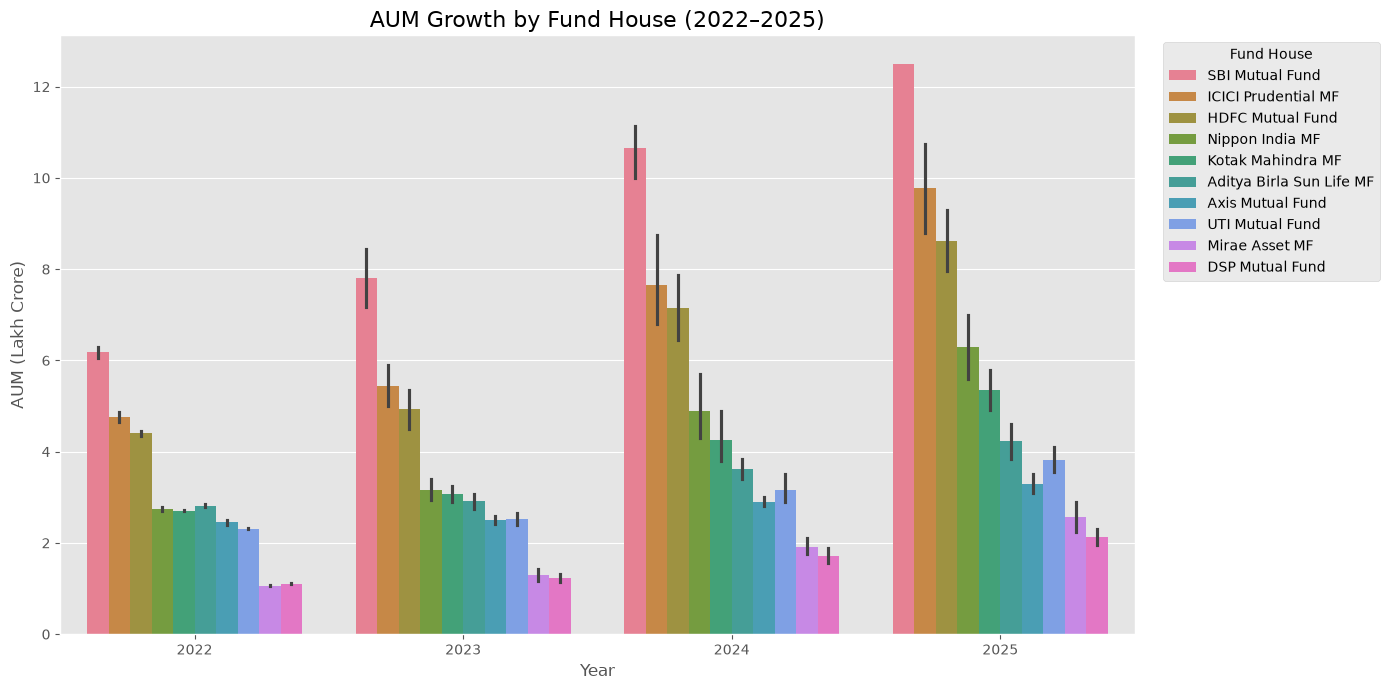

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14,7))

sns.barplot(
    data=aum,
    x="year",
    y="aum_lakh_crore",
    hue="fund_house"
)

plt.title("AUM Growth by Fund House (2022–2025)", fontsize=16)
plt.xlabel("Year")
plt.ylabel("AUM (Lakh Crore)")
plt.xticks(rotation=0)

plt.legend(
    title="Fund House",
    bbox_to_anchor=(1.02,1),
    loc="upper left"
)

plt.tight_layout()

plt.show()

In [26]:
print(sip.head())

     month  sip_inflow_crore  active_sip_accounts_crore  \
0  2022-01             11517                       4.91   
1  2022-02             11438                       4.93   
2  2022-03             12328                       5.09   
3  2022-04             11863                       5.48   
4  2022-05             12286                       5.55   

   new_sip_accounts_lakh  sip_aum_lakh_crore  yoy_growth_pct  
0                   9.10                4.80             NaN  
1                   8.20                4.85             NaN  
2                  10.50                5.01             NaN  
3                   9.52                5.12             NaN  
4                   8.10                5.15             NaN  


In [27]:
print(sip.columns.tolist())

['month', 'sip_inflow_crore', 'active_sip_accounts_crore', 'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct']


In [28]:
# Convert month to datetime
sip["month"] = pd.to_datetime(sip["month"])

sip.head()

,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
0,2022-01-01,11517,4.91,9.10,4.80,NaN
1,2022-02-01,11438,4.93,8.20,4.85,NaN
2,2022-03-01,12328,5.09,10.50,5.01,NaN
3,2022-04-01,11863,5.48,9.52,5.12,NaN
4,2022-05-01,12286,5.55,8.10,5.15,NaN


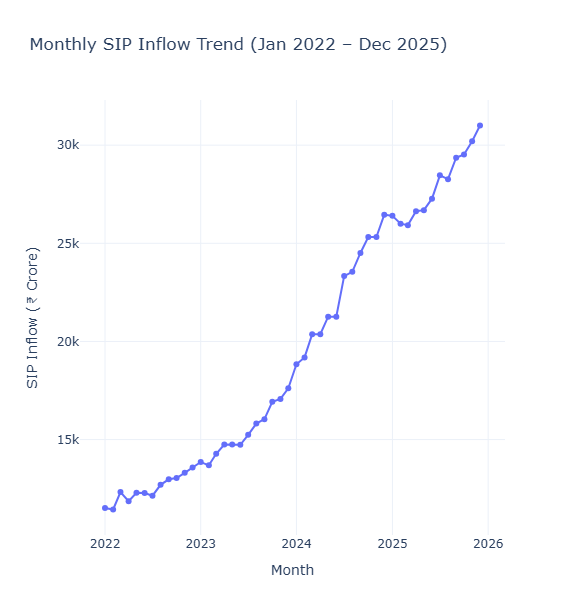

In [29]:
import plotly.express as px

fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    markers=True,
    title="Monthly SIP Inflow Trend (Jan 2022 – Dec 2025)",
    labels={
        "month": "Month",
        "sip_inflow_crore": "SIP Inflow (₹ Crore)"
    }
)

fig.update_layout(
    template="plotly_white",
    width=1200,
    height=600
)

fig.show()

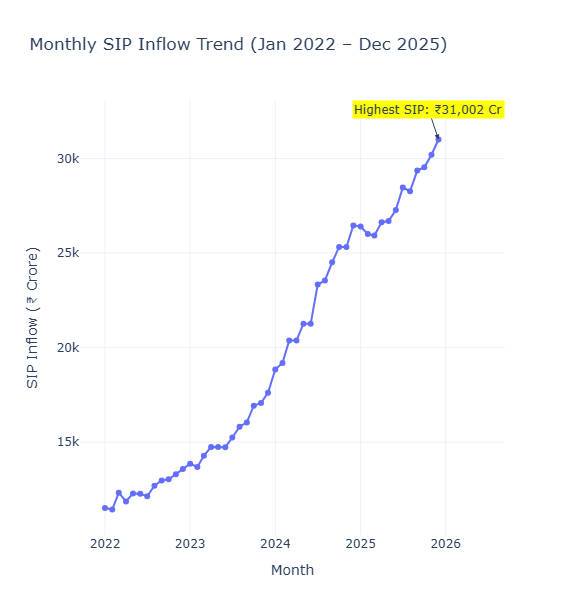

In [30]:
max_row = sip.loc[sip["sip_inflow_crore"].idxmax()]

fig.add_annotation(
    x=max_row["month"],
    y=max_row["sip_inflow_crore"],
    text=f"Highest SIP: ₹{max_row['sip_inflow_crore']:,} Cr",
    showarrow=True,
    arrowhead=2,
    bgcolor="yellow"
)

fig.show()

In [31]:
fig.write_html("charts/sip_inflow_trend.html")

FileNotFoundError: [Errno 2] No such file or directory: 'charts\\sip_inflow_trend.html'

In [32]:
import os
print(os.listdir())

['.git', '.gitignore', '.ipynb_checkpoints', 'amfi_validation.py', 'clean_investor_transactions.py', 'clean_nav_history.py', 'clean_scheme_performance.py', 'dashboard', 'data', 'database', 'data_dictionary.md', 'data_ingestion.py', 'EDA_Analysis.ipynb', 'explore_fund_master.py', 'live_nav_fetch.py', 'load_to_sqlite.py', 'notebooks', 'reports', 'requirements.txt', 'scripts', 'sql', 'venv']


In [33]:
import os

os.makedirs("charts", exist_ok=True)

print("Charts folder created successfully!")

Charts folder created successfully!


In [34]:
print(os.listdir())

['.git', '.gitignore', '.ipynb_checkpoints', 'amfi_validation.py', 'charts', 'clean_investor_transactions.py', 'clean_nav_history.py', 'clean_scheme_performance.py', 'dashboard', 'data', 'database', 'data_dictionary.md', 'data_ingestion.py', 'EDA_Analysis.ipynb', 'explore_fund_master.py', 'live_nav_fetch.py', 'load_to_sqlite.py', 'notebooks', 'reports', 'requirements.txt', 'scripts', 'sql', 'venv']


In [35]:
print(os.listdir())

['.git', '.gitignore', '.ipynb_checkpoints', 'amfi_validation.py', 'charts', 'clean_investor_transactions.py', 'clean_nav_history.py', 'clean_scheme_performance.py', 'dashboard', 'data', 'database', 'data_dictionary.md', 'data_ingestion.py', 'EDA_Analysis.ipynb', 'explore_fund_master.py', 'live_nav_fetch.py', 'load_to_sqlite.py', 'notebooks', 'reports', 'requirements.txt', 'scripts', 'sql', 'venv']


In [36]:
fig.write_html("charts/sip_inflow_trend.html")

In [37]:
import os

folders = [
    "charts",
    "charts/plotly",
    "charts/seaborn",
    "charts/matplotlib"
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("Folders created successfully!")

Folders created successfully!


In [38]:
fig.write_html("charts/plotly/sip_inflow_trend.html")

In [39]:
plt.savefig("charts/seaborn/aum_growth.png", dpi=300)

<Figure size 640x480 with 0 Axes>

In [40]:
import os
print(os.listdir("charts"))

['matplotlib', 'plotly', 'seaborn', 'sip_inflow_trend.html']


In [41]:
import os
os.makedirs("charts", exist_ok=True)

fig.write_html("charts/sip_inflow_trend.html")

print("Chart saved successfully!")

Chart saved successfully!


In [42]:
print(os.listdir("charts"))

['matplotlib', 'plotly', 'seaborn', 'sip_inflow_trend.html']


In [43]:
print(category.head())

     month         category  net_inflow_crore
0  2024-04        Large Cap            2413.0
1  2024-04          Mid Cap            3897.0
2  2024-04        Small Cap            3533.0
3  2024-04        Flexi Cap            4947.0
4  2024-04  Large & Mid Cap            4214.0


In [44]:
print(category.columns.tolist())

['month', 'category', 'net_inflow_crore']


In [45]:
category["month"] = pd.to_datetime(category["month"])
category["month"] = category["month"].dt.strftime("%b-%Y")

category.head()

,month,category,net_inflow_crore
0,Apr-2024,Large Cap,2413.0
1,Apr-2024,Mid Cap,3897.0
2,Apr-2024,Small Cap,3533.0
3,Apr-2024,Flexi Cap,4947.0
4,Apr-2024,Large & Mid Cap,4214.0


In [46]:
heatmap_data = category.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

heatmap_data

month,Apr-2024,Aug-2024,Dec-2024,Feb-2025,Jan-2025,Jul-2024,Jun-2024,Mar-2025,May-2024,Nov-2024,Oct-2024,Sep-2024
category,,,,,,,,,,,,
ELSS,466.0,499.0,521.0,437.0,516.0,471.0,472.0,500.0,553.0,571.0,537.0,537.0
Flexi Cap,4947.0,5562.0,4654.0,6068.0,5603.0,4869.0,4478.0,4767.0,5529.0,6111.0,6004.0,5397.0
Gilt,784.0,952.0,831.0,942.0,744.0,959.0,864.0,956.0,836.0,704.0,898.0,925.0
Hybrid,2955.0,3684.0,3538.0,3360.0,2967.0,3291.0,3163.0,2830.0,3487.0,3264.0,3314.0,3015.0
Large & Mid Cap,4214.0,5411.0,4878.0,5524.0,4816.0,5023.0,4610.0,4243.0,4368.0,5556.0,4581.0,4528.0
Large Cap,2413.0,1940.0,1923.0,1925.0,2025.0,2574.0,2519.0,2234.0,2076.0,1870.0,2255.0,1879.0
Liquid,37537.0,41952.0,34933.0,32374.0,33892.0,34643.0,40486.0,38681.0,41872.0,40506.0,39091.0,35308.0
Mid Cap,3897.0,3899.0,5023.0,4819.0,4316.0,4548.0,5047.0,5061.0,5300.0,4336.0,4106.0,4960.0
Sectoral/Thematic,8052.0,8360.0,9820.0,9215.0,7893.0,9896.0,10030.0,8614.0,8354.0,7397.0,7680.0,8518.0


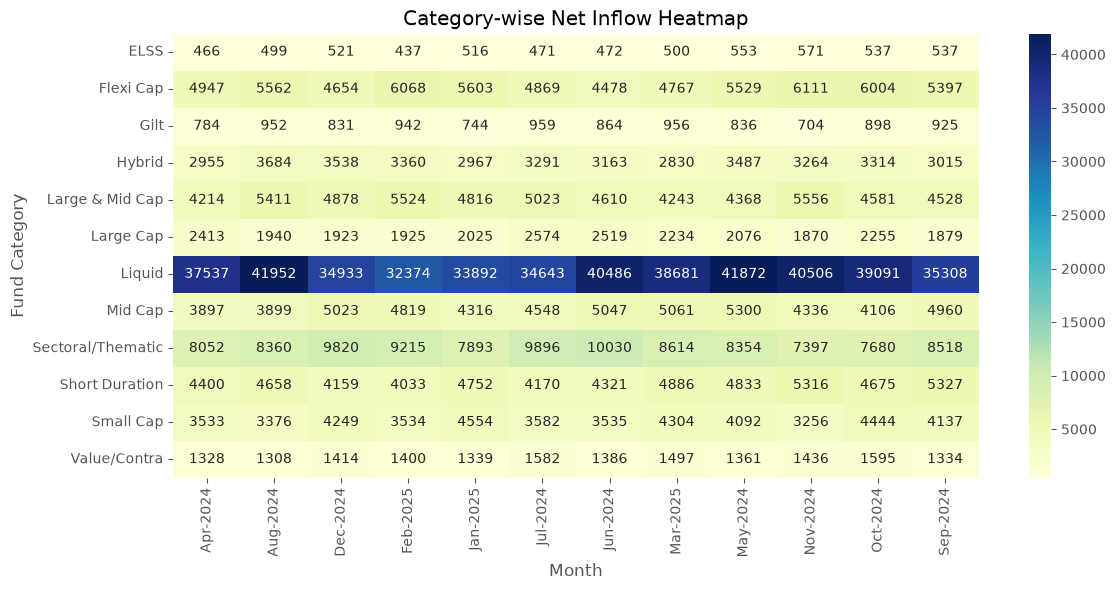

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))

sns.heatmap(
    heatmap_data,
    annot=True,
    cmap="YlGnBu",
    fmt=".0f"
)

plt.title("Category-wise Net Inflow Heatmap")
plt.xlabel("Month")
plt.ylabel("Fund Category")

plt.tight_layout()

plt.show()

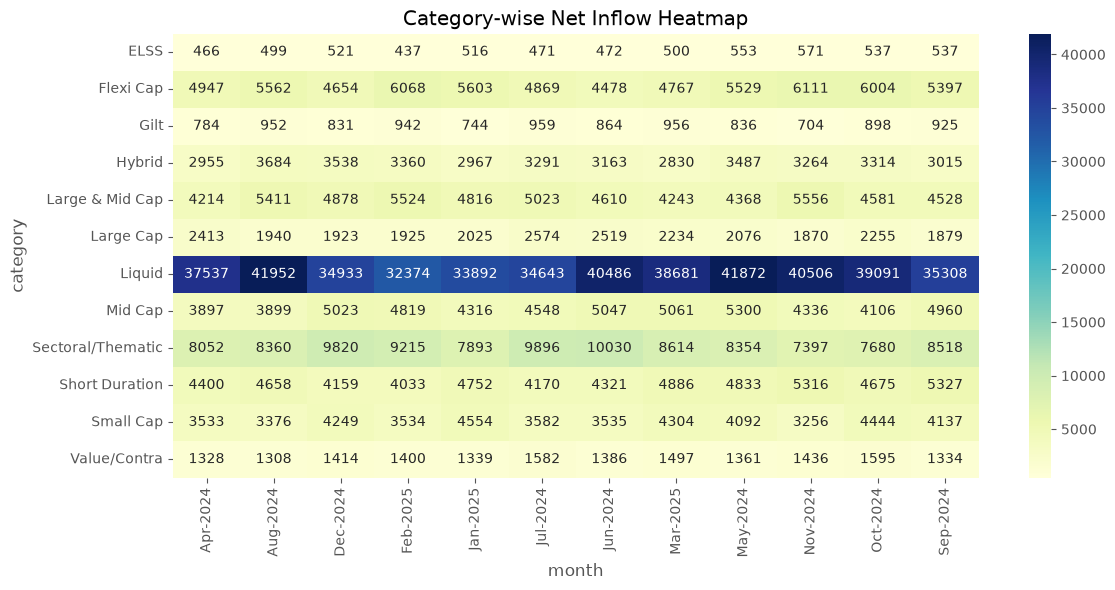

In [49]:
plt.figure(figsize=(12,6))

sns.heatmap(
    heatmap_data,
    annot=True,
    cmap="YlGnBu",
    fmt=".0f"
)

plt.title("Category-wise Net Inflow Heatmap")

plt.tight_layout()

plt.savefig("charts/seaborn/category_inflow_heatmap.png", dpi=300)

plt.show()

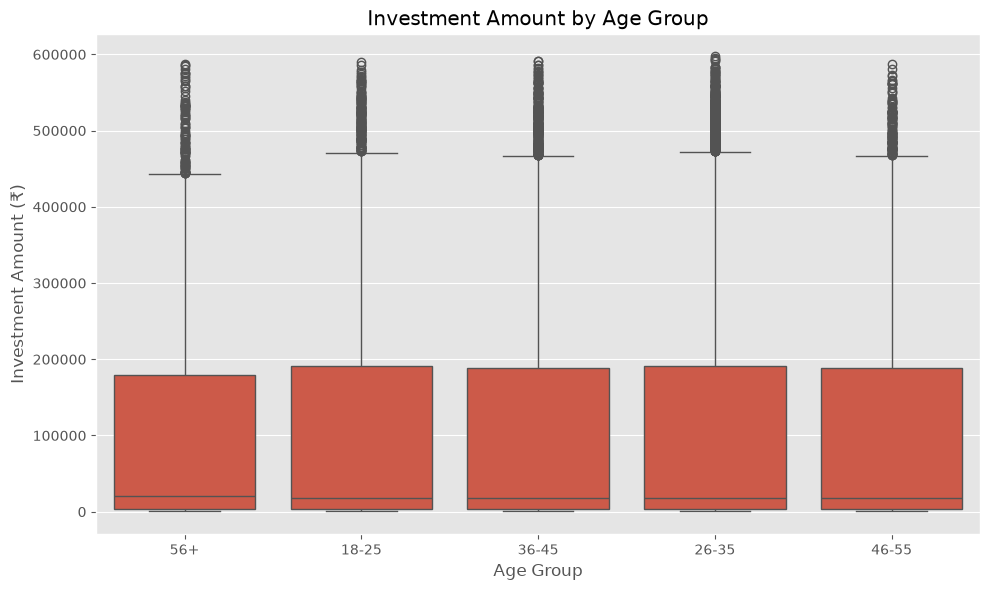

In [50]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=transactions,
    x="age_group",
    y="amount_inr"
)

plt.title("Investment Amount by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Investment Amount (₹)")

plt.tight_layout()

plt.savefig("charts/seaborn/sip_amount_boxplot.png", dpi=300)

plt.show()

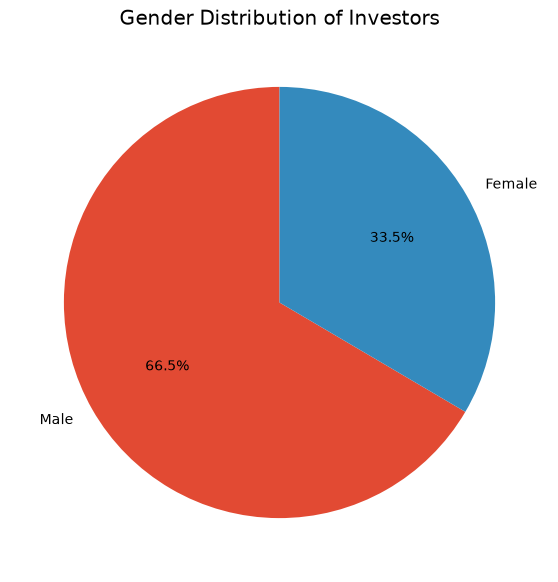

In [51]:
gender_counts = transactions["gender"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Gender Distribution of Investors")

plt.savefig("charts/matplotlib/gender_distribution.png", dpi=300)

plt.show()

In [52]:
print(transactions.columns.tolist())

['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status']


In [53]:
print(transactions.head())

  investor_id transaction_date  amfi_code transaction_type  amount_inr  \
0   INV003054       2024-01-01     119092              Sip        1834   
1   INV002952       2024-01-01     148567       Redemption      392882   
2   INV003420       2024-01-01     118636              Sip         912   
3   INV003436       2024-01-01     118634              Sip        1102   
4   INV004691       2024-01-01     119094          Lumpsum        8682   

         state       city city_tier age_group  gender  annual_income_lakh  \
0    Telangana  Hyderabad       T30       56+  Female                77.1   
1       Punjab   Amritsar       B30     18-25    Male                 7.1   
2      Haryana  Faridabad       B30     36-45    Male                47.2   
3  Maharashtra     Mumbai       T30     36-45  Female                54.4   
4        Delhi      Noida       T30     26-35    Male                14.5   

  payment_mode kyc_status  
0          UPI   Verified  
1       Cheque   Verified  
2      M

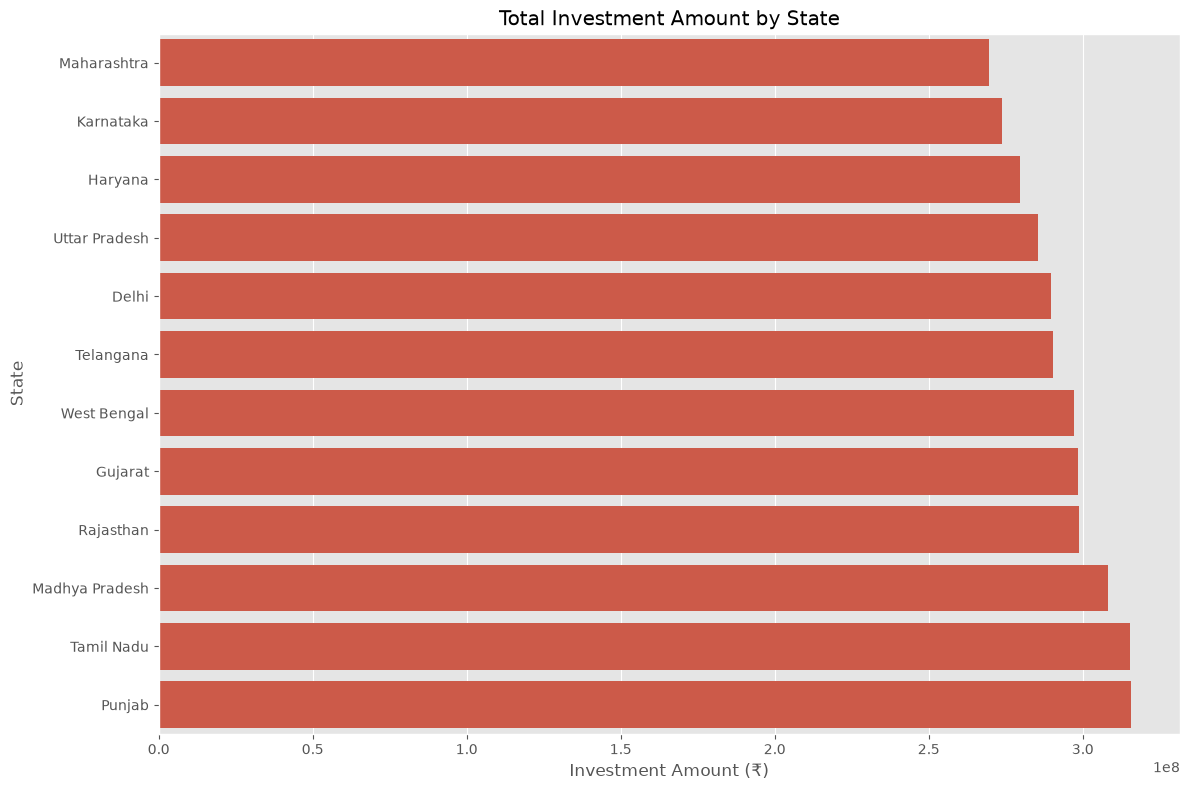

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sum SIP amount by state
state_sip = transactions.groupby("state")["amount_inr"].sum().sort_values()

plt.figure(figsize=(12,8))

sns.barplot(
    x=state_sip.values,
    y=state_sip.index
)

plt.title("Total Investment Amount by State")
plt.xlabel("Investment Amount (₹)")
plt.ylabel("State")

plt.tight_layout()

plt.savefig("charts/seaborn/state_sip_amount.png", dpi=300)

plt.show()

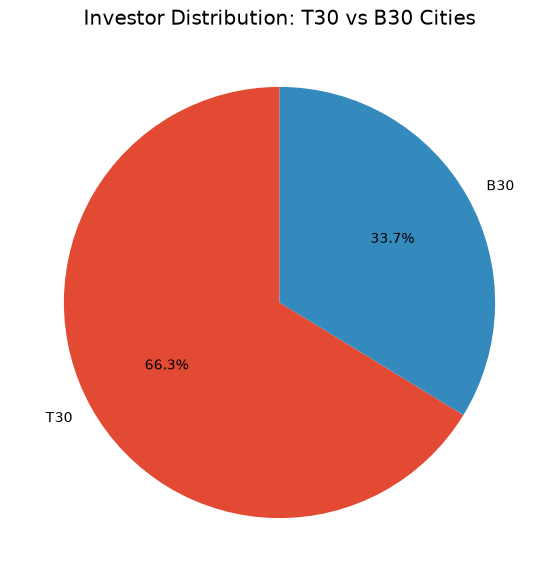

In [55]:
city_counts = transactions["city_tier"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    city_counts,
    labels=city_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Investor Distribution: T30 vs B30 Cities")

plt.savefig("charts/matplotlib/t30_b30_distribution.png", dpi=300)

plt.show()

In [56]:
print(folio.head())
print(folio.columns.tolist())

     month  total_folios_crore  equity_folios_crore  debt_folios_crore  \
0  2022-01               13.26                 9.28               1.86   
1  2022-04               13.91                 9.74               1.95   
2  2022-07               13.85                 9.69               1.94   
3  2022-10               14.12                 9.88               1.98   
4  2023-01               14.81                10.37               2.07   

   hybrid_folios_crore  others_folios_crore  
0                 0.80                 1.33  
1                 0.83                 1.39  
2                 0.83                 1.38  
3                 0.85                 1.41  
4                 0.89                 1.48  
['month', 'total_folios_crore', 'equity_folios_crore', 'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore']


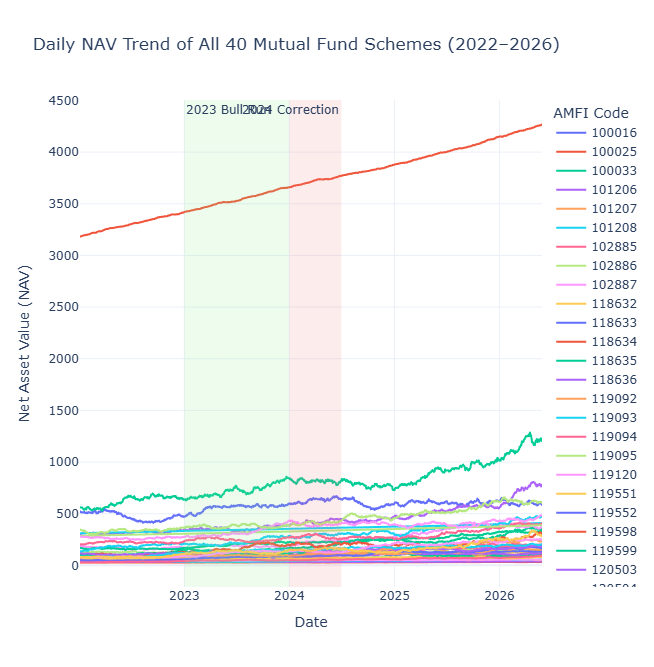

In [15]:
import plotly.express as px

fig = px.line(
    nav,
    x="date",
    y="nav",
    color="amfi_code",
    title="Daily NAV Trend of All 40 Mutual Fund Schemes (2022–2026)",
    labels={
        "date": "Date",
        "nav": "Net Asset Value (NAV)",
        "amfi_code": "AMFI Code"
    }
)

# Highlight 2023 Bull Run
fig.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    fillcolor="lightgreen",
    opacity=0.15,
    line_width=0,
    annotation_text="2023 Bull Run",
    annotation_position="top left"
)

# Highlight 2024 Market Correction
fig.add_vrect(
    x0="2024-01-01",
    x1="2024-06-30",
    fillcolor="lightcoral",
    opacity=0.15,
    line_width=0,
    annotation_text="2024 Correction",
    annotation_position="top right"
)

fig.update_layout(
    template="plotly_white",
    width=1300,
    height=650
)

fig.show()

In [57]:
import os
os.makedirs("charts/plotly", exist_ok=True)

fig.write_html("charts/plotly/nav_trend_all_schemes.html")

In [58]:
import os
print(os.listdir("charts/plotly"))

['nav_trend_all_schemes.html', 'sip_inflow_trend.html']


In [59]:
# Convert NAV data into wide format
nav_returns = nav.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)

# Calculate daily percentage returns
returns = nav_returns.pct_change()

returns.head()

amfi_code,100016,100025,100033,101206,101207,101208,102885,102886,102887,118632,...,120843,120844,125497,125498,148567,148568,148569,149322,149323,149324
date,,,,,,,,,,,,,,,,,,,,,
2022-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-01-04,-0.010306,-0.003553,-0.013328,0.001153,-0.010865,-0.000141,0.011122,0.011314,-0.010459,-0.000714,...,0.018160,0.000243,0.001001,-0.005010,0.019318,0.015865,0.008378,-0.008592,0.000482,-0.010498
2022-01-05,0.012865,-0.000050,-0.004386,0.003866,0.000603,0.000382,-0.007878,0.006779,-0.005308,0.005913,...,-0.012304,0.000462,0.004250,-0.005184,-0.003939,-0.007660,0.015294,-0.006480,0.008670,-0.002593
2022-01-06,-0.011377,-0.001880,-0.005167,-0.002128,-0.029101,-0.000143,0.015277,0.031127,0.012678,0.003540,...,0.008509,0.000650,-0.003589,-0.002706,0.011892,-0.004709,0.000863,-0.003818,-0.013861,-0.008382
2022-01-07,-0.001210,0.002036,-0.005748,-0.006314,0.024766,0.000215,-0.009369,-0.008835,-0.016498,-0.005793,...,-0.013477,0.000176,-0.002719,-0.012660,0.000515,0.007001,0.001173,-0.004069,0.004317,0.011680


In [60]:
selected_returns = returns.iloc[:, :10]
selected_returns.head()

amfi_code,100016,100025,100033,101206,101207,101208,102885,102886,102887,118632
date,,,,,,,,,,
2022-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-01-04,-0.010306,-0.003553,-0.013328,0.001153,-0.010865,-0.000141,0.011122,0.011314,-0.010459,-0.000714
2022-01-05,0.012865,-0.000050,-0.004386,0.003866,0.000603,0.000382,-0.007878,0.006779,-0.005308,0.005913
2022-01-06,-0.011377,-0.001880,-0.005167,-0.002128,-0.029101,-0.000143,0.015277,0.031127,0.012678,0.003540
2022-01-07,-0.001210,0.002036,-0.005748,-0.006314,0.024766,0.000215,-0.009369,-0.008835,-0.016498,-0.005793


In [61]:
corr = selected_returns.corr()

corr

amfi_code,100016,100025,100033,101206,101207,101208,102885,102886,102887,118632
amfi_code,,,,,,,,,,
100016,1.000000,0.045567,-0.000006,0.027747,0.016053,-0.033773,-0.093533,-0.005867,-0.023316,-0.026781
100025,0.045567,1.000000,0.002150,0.023769,-0.006710,0.018455,-0.001038,0.013754,-0.005648,-0.014166
100033,-0.000006,0.002150,1.000000,-0.018079,0.000351,0.007864,-0.034228,-0.018166,-0.036647,-0.013318
101206,0.027747,0.023769,-0.018079,1.000000,0.010202,-0.027230,0.001570,0.007229,-0.006490,-0.005432
101207,0.016053,-0.006710,0.000351,0.010202,1.000000,-0.007530,-0.005929,0.004860,0.002304,0.043384
101208,-0.033773,0.018455,0.007864,-0.027230,-0.007530,1.000000,-0.001436,0.014307,0.036547,0.003507
102885,-0.093533,-0.001038,-0.034228,0.001570,-0.005929,-0.001436,1.000000,0.020691,-0.036704,-0.000285
102886,-0.005867,0.013754,-0.018166,0.007229,0.004860,0.014307,0.020691,1.000000,-0.007865,-0.039886
102887,-0.023316,-0.005648,-0.036647,-0.006490,0.002304,0.036547,-0.036704,-0.007865,1.000000,0.001248


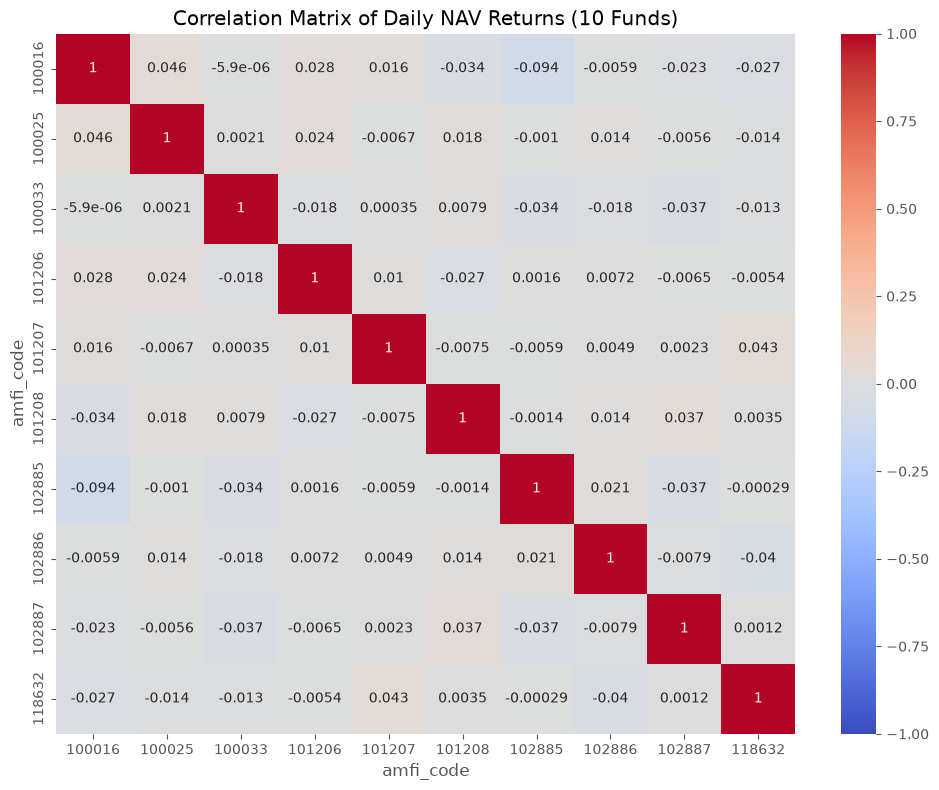

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.title("Correlation Matrix of Daily NAV Returns (10 Funds)")

plt.tight_layout()

plt.savefig(
    "charts/seaborn/nav_return_correlation.png",
    dpi=300
)

plt.show()

In [63]:
print(holdings.head())

   amfi_code stock_symbol                stock_name       sector  weight_pct  \
0     119551    POWERGRID    Power Grid Corporation    Utilities       13.85   
1     119551     HDFCBANK             HDFC Bank Ltd      Banking       11.19   
2     119551       GRASIM     Grasim Industries Ltd  Diversified        9.90   
3     119551      DRREDDY  Dr. Reddy's Laboratories       Pharma        4.76   
4     119551   ASIANPAINT          Asian Paints Ltd       Paints       10.25   

   market_value_cr  current_price_inr portfolio_date  
0           737.09            6011.08     2025-12-31  
1            88.97            1074.65     2025-12-31  
2           208.45            5964.59     2025-12-31  
3           161.32            3748.82     2025-12-31  
4           725.90            1321.45     2025-12-31  


In [64]:
print(holdings.columns.tolist())

['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']


In [65]:
print(holdings.head())

   amfi_code stock_symbol                stock_name       sector  weight_pct  \
0     119551    POWERGRID    Power Grid Corporation    Utilities       13.85   
1     119551     HDFCBANK             HDFC Bank Ltd      Banking       11.19   
2     119551       GRASIM     Grasim Industries Ltd  Diversified        9.90   
3     119551      DRREDDY  Dr. Reddy's Laboratories       Pharma        4.76   
4     119551   ASIANPAINT          Asian Paints Ltd       Paints       10.25   

   market_value_cr  current_price_inr portfolio_date  
0           737.09            6011.08     2025-12-31  
1            88.97            1074.65     2025-12-31  
2           208.45            5964.59     2025-12-31  
3           161.32            3748.82     2025-12-31  
4           725.90            1321.45     2025-12-31  


In [66]:
print(holdings.columns.tolist())

['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']


In [67]:
print(holdings.head())

   amfi_code stock_symbol                stock_name       sector  weight_pct  \
0     119551    POWERGRID    Power Grid Corporation    Utilities       13.85   
1     119551     HDFCBANK             HDFC Bank Ltd      Banking       11.19   
2     119551       GRASIM     Grasim Industries Ltd  Diversified        9.90   
3     119551      DRREDDY  Dr. Reddy's Laboratories       Pharma        4.76   
4     119551   ASIANPAINT          Asian Paints Ltd       Paints       10.25   

   market_value_cr  current_price_inr portfolio_date  
0           737.09            6011.08     2025-12-31  
1            88.97            1074.65     2025-12-31  
2           208.45            5964.59     2025-12-31  
3           161.32            3748.82     2025-12-31  
4           725.90            1321.45     2025-12-31  


In [68]:
print(holdings.columns.tolist())

['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']


In [69]:
sector_data = holdings.groupby("sector")["weight_pct"].sum().sort_values(ascending=False)

sector_data

sector
Banking           652.26
IT                455.47
Pharma            407.45
Automobile        323.65
Utilities         265.54
FMCG              229.11
Infrastructure    192.16
Diversified       169.23
Telecom           145.62
Consumer Goods    127.61
NBFC              119.09
Energy            117.91
Cement            105.03
Paints             89.86
Name: weight_pct, dtype: float64

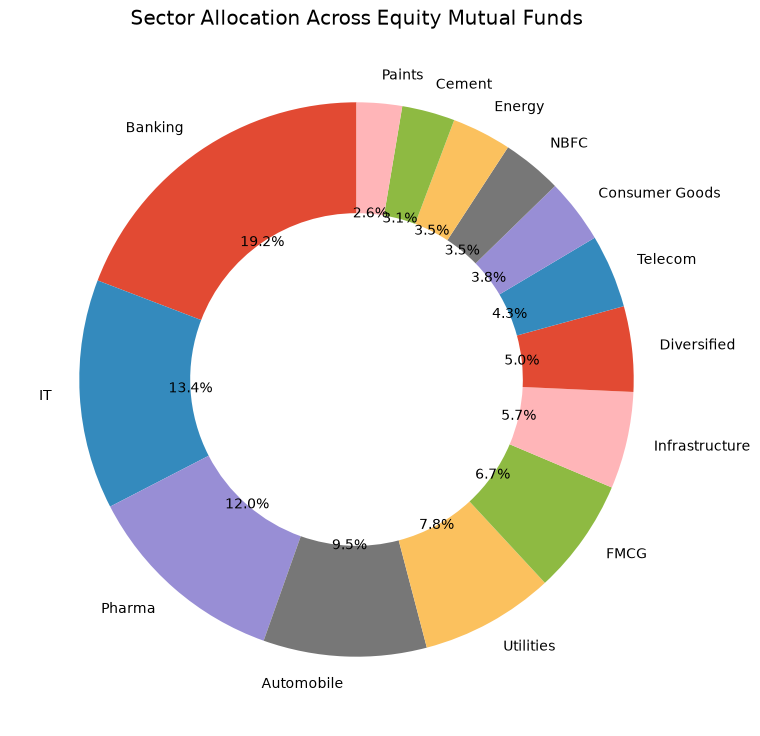

In [70]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9,9))

plt.pie(
    sector_data,
    labels=sector_data.index,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops=dict(width=0.4)
)

plt.title("Sector Allocation Across Equity Mutual Funds")

plt.savefig(
    "charts/matplotlib/sector_allocation_donut.png",
    dpi=300
)

plt.show()

In [71]:
Performance_Analytics.ipynb

NameError: name 'Performance_Analytics' is not defined